In [2]:
%%writefile experiments.py
import time
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

START, END = "2005-01-01", "2026-01-01"
TEST_START = pd.Timestamp("2021-01-01")
BLOCK = 63
COST_BPS = 5
N_PERM = 1000
EXPERIMENTS = [("SPY", 1), ("SPY", 5), ("^NSEI", 1), ("^NSEI", 5), ("AAPL", 1)]


def load(ticker):
    for attempt in range(5):
        try:
            df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            df = df.loc[:, ~df.columns.duplicated()]
            cols = ["Open", "High", "Low", "Close", "Volume"]
            if all(c in df.columns for c in cols):
                df = df[cols].dropna()
                df = df[df["Close"] > 0]
                if len(df) > 1000:
                    df.index = pd.to_datetime(df.index).tz_localize(None)
                    return df
            print(f"  {ticker}: bad or empty download, retrying...")
        except Exception as e:
            print(f"  {ticker}: download error ({e}), retrying...")
        time.sleep(10)
    raise RuntimeError(f"Could not download {ticker}")


def rsi(close, n=14):
    d = close.diff()
    up = d.clip(lower=0).ewm(alpha=1 / n, adjust=False).mean()
    down = (-d.clip(upper=0)).ewm(alpha=1 / n, adjust=False).mean()
    return 100 - 100 / (1 + up / down)


def make_features(df, vix, use_volume):
    c, r = df["Close"], df["Close"].pct_change()
    f = pd.DataFrame(index=df.index)
    for k in [1, 2, 3, 5, 10, 21]:
        f[f"ret_{k}d"] = c.pct_change(k)
    for w in [10, 21, 63]:
        f[f"vol_{w}d"] = r.rolling(w).std()
    for w in [10, 50, 200]:
        f[f"px_vs_sma{w}"] = c / c.rolling(w).mean() - 1
    f["rsi_14"] = rsi(c)
    macd = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    f["macd_hist"] = (macd - macd.ewm(span=9, adjust=False).mean()) / c
    f["hl_range"] = (df["High"] - df["Low"]) / c
    if use_volume:
        v = df["Volume"]
        f["volume_z"] = (v - v.rolling(21).mean()) / v.rolling(21).std()
    f["day_of_week"] = df.index.dayofweek
    f["vix"] = vix
    f["vix_chg5"] = vix.pct_change(5)
    f["vix_vs_ma21"] = vix / vix.rolling(21).mean()
    return f


def make_dataset(df, vix, h, use_volume):
    X = make_features(df, vix, use_volume)
    fwd = df["Close"].shift(-h) / df["Close"] - 1
    data = X.assign(fwd=fwd).replace([np.inf, -np.inf], np.nan).dropna()
    y = (data["fwd"] > 0).astype(int)
    return data.drop(columns="fwd"), y, data["fwd"]


def model_specs():
    return {
        "Always Up": (DummyClassifier(strategy="constant", constant=1), None),
        "Logistic Reg": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
                         {"logisticregression__C": [0.01, 0.1, 1.0]}),
        "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                          {"max_depth": [3, 5, 8], "min_samples_leaf": [20, 50, 100]}),
        "SVM": (make_pipeline(StandardScaler(), SVC(kernel="rbf")),
                {"svc__C": [0.1, 1.0, 10.0], "svc__gamma": ["scale", 0.01]}),
    }


def get_score(m, X):
    return m.predict_proba(X)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(X)


def tune(model, grid, X, y, h):
    gs = GridSearchCV(model, grid, cv=TimeSeriesSplit(n_splits=5, gap=h + 5),
                      scoring="roc_auc", n_jobs=-1)
    gs.fit(X, y)
    return gs.best_estimator_, gs.best_params_, gs.best_score_


def walk_forward(model, X, y, h):
    test_idx = X.index[X.index >= TEST_START]
    preds = pd.Series(index=test_idx, dtype=float)
    scores = pd.Series(index=test_idx, dtype=float)
    for i in range(0, len(test_idx), BLOCK):
        block = test_idx[i:i + BLOCK]
        train_idx = X.index[X.index < block[0]][:-h]
        m = clone(model).fit(X.loc[train_idx], y.loc[train_idx])
        preds[block] = m.predict(X.loc[block])
        scores[block] = get_score(m, X.loc[block])
    return preds.astype(int), scores


def backtest(signal, fwd, h):
    sig, ret = signal.iloc[::h], fwd.iloc[::h]
    turnover = sig.diff().abs().fillna(sig.iloc[0])
    return sig * ret - turnover * COST_BPS / 1e4, ret


def perf(ret, h):
    ppy = 252 / h
    eq = (1 + ret).cumprod()
    cagr = eq.iloc[-1] ** (ppy / len(ret)) - 1
    sd = ret.std()
    return {"CAGR": cagr, "Vol": sd * np.sqrt(ppy),
            "Sharpe": ret.mean() / sd * np.sqrt(ppy) if sd > 0 else np.nan,
            "MaxDD": (eq / eq.cummax() - 1).min()}, eq


def perm_pvalue(y_true, scores, actual_auc, rng):
    if np.unique(scores).size < 2:
        return 1.0
    yv, sv = y_true.values, scores.values
    hits = sum(roc_auc_score(rng.permutation(yv), sv) >= actual_auc for _ in range(N_PERM))
    return (hits + 1) / (N_PERM + 1)


def run_experiment(ticker, h, vix_raw, rng):
    name = f"{ticker} {h}d"
    print("\n" + "=" * 90 + f"\nEXPERIMENT: {name}\n" + "=" * 90)
    df = load(ticker)
    lag = 1 if (ticker.startswith("^NSE") or ticker.endswith(".NS")) else 0
    vix = vix_raw.reindex(df.index.union(vix_raw.index)).ffill().shift(lag).reindex(df.index)
    v = df["Volume"]
    use_volume = (v.isna() | (v <= 0)).mean() < 0.05
    if not use_volume:
        print("  Volume data unreliable for this ticker -> volume feature dropped")
    X, y, fwd = make_dataset(df, vix, h, use_volume)
    tr = X.index < TEST_START
    print(f"  {tr.sum()} training rows, {(~tr).sum()} test rows, "
          f"{len(X.columns)} features, up-share (train) {y[tr].mean():.3f}")
    y_te, fwd_te = y[~tr], fwd[~tr]
    rows, curves, rf_imp = [], {}, None
    for mname, (model, grid) in model_specs().items():
        if grid:
            model, params, cv_auc = tune(model, grid, X[tr], y[tr], h)
            print(f"  {mname:<14} best {params}  CV AUC {cv_auc:.3f}")
        if mname == "Random Forest":
            rf_imp = pd.Series(clone(model).fit(X[tr], y[tr]).feature_importances_, index=X.columns)
        preds, scores = walk_forward(model, X, y, h)
        auc = roc_auc_score(y_te, scores) if np.unique(scores).size > 1 else 0.5
        strat, _ = backtest(preds, fwd_te, h)
        stats, eq = perf(strat, h)
        rows.append({"Experiment": name, "Model": mname,
                     "Accuracy": accuracy_score(y_te, preds),
                     "BalAcc": balanced_accuracy_score(y_te, preds),
                     "AUC": auc, "p_value": perm_pvalue(y_te, scores, auc, rng),
                     "Exposure": preds.mean(), **stats})
        curves[mname] = eq
    bh_ret = fwd_te.iloc[::h]
    bh_stats, bh_eq = perf(bh_ret, h)
    rows.append({"Experiment": name, "Model": "Buy & Hold", "Accuracy": np.nan, "BalAcc": np.nan,
                 "AUC": np.nan, "p_value": np.nan, "Exposure": 1.0, **bh_stats})
    curves["Buy & Hold"] = bh_eq
    table = pd.DataFrame(rows)
    table["BH_Sharpe"] = bh_stats["Sharpe"]
    print("\n" + table.drop(columns=["Experiment", "BH_Sharpe"]).set_index("Model").round(3).to_string())
    return table, curves, rf_imp


def main():
    rng = np.random.default_rng(42)
    print("Downloading VIX...")
    vix_raw = load("^VIX")["Close"]
    tables, all_curves, spy_imp = [], {}, None
    for ticker, h in EXPERIMENTS:
        try:
            table, curves, imp = run_experiment(ticker, h, vix_raw, rng)
        except Exception as e:
            print(f"  !! Experiment {ticker} {h}d failed: {e}")
            continue
        tables.append(table)
        all_curves[f"{ticker} {h}d"] = curves
        if ticker == "SPY" and h == 1:
            spy_imp = imp
    summary = pd.concat(tables, ignore_index=True)
    summary.to_csv("summary.csv", index=False)
    cols = ["Experiment", "Model", "AUC", "p_value", "BalAcc", "Sharpe", "BH_Sharpe", "MaxDD", "Exposure"]
    print("\n" + "=" * 90 + "\nCOMBINED SUMMARY (test period 2021 onward)\n" + "=" * 90)
    print(summary[cols].round(3).to_string(index=False))
    n = len(all_curves)
    fig, axes = plt.subplots(n, 1, figsize=(11, 4 * n))
    axes = np.atleast_1d(axes)
    for ax, (exp, curves) in zip(axes, all_curves.items()):
        pd.DataFrame(curves).plot(ax=ax, title=f"{exp}: out-of-sample equity (growth of 1)")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("equity_curves_all.png", dpi=110)
    plt.close()
    if spy_imp is not None:
        top = spy_imp.sort_values(ascending=False).head(10)[::-1]
        top.plot(kind="barh", figsize=(8, 5), title="Top 10 Random Forest features (SPY 1d)")
        plt.tight_layout()
        plt.savefig("feature_importance.png", dpi=110)
        plt.close()
        print("\nTop 10 Random Forest features (SPY 1d):")
        print(spy_imp.sort_values(ascending=False).head(10).round(3).to_string())
    models = summary[summary["Model"] != "Buy & Hold"]
    sig = models[(models["p_value"] < 0.05) & (models["Model"] != "Always Up")]
    beat = models[(models["Sharpe"] > models["BH_Sharpe"]) & (models["Model"] != "Always Up")]
    print("\n" + "=" * 90 + "\nVERDICT\n" + "=" * 90)
    print(f"Statistically significant AUC (p < 0.05): "
          f"{', '.join(sig['Experiment'] + ' / ' + sig['Model']) if len(sig) else 'NONE'}")
    print(f"Models with higher Sharpe than Buy & Hold: "
          f"{', '.join(beat['Experiment'] + ' / ' + beat['Model']) if len(beat) else 'NONE'}")
    print(f"(Tests run: {len(models[models['Model'] != 'Always Up'])}. At p < 0.05, about 1 in 20 "
          f"will look significant by pure chance.)")
    print("\nDONE. Saved summary.csv, equity_curves_all.png, feature_importance.png")


if __name__ == "__main__":
    main()

Writing experiments.py



EXPERIMENT: SPY 1d
  3829 training rows, 1254 test rows, 20 features, up-share (train) 0.554
  Logistic Reg   best {'logisticregression__C': 0.01}  CV AUC 0.500
  Random Forest  best {'max_depth': 5, 'min_samples_leaf': 100}  CV AUC 0.497
  SVM            best {'svc__C': 0.1, 'svc__gamma': 'scale'}  CV AUC 0.506

               Accuracy  BalAcc    AUC  p_value  Exposure   CAGR    Vol  Sharpe  MaxDD
Model                                                                                 
Always Up         0.547   0.500  0.500    1.000     1.000  0.147  0.171   0.888 -0.245
Logistic Reg      0.548   0.502  0.502    0.461     0.983  0.144  0.169   0.881 -0.260
Random Forest     0.543   0.500  0.512    0.246     0.961  0.136  0.169   0.840 -0.253
SVM               0.547   0.500  0.512    0.248     1.000  0.147  0.171   0.888 -0.245
Buy & Hold          NaN     NaN    NaN      NaN     1.000  0.147  0.171   0.888 -0.245

EXPERIMENT: SPY 5d
  3829 training rows, 1250 test rows, 20 features, up-s

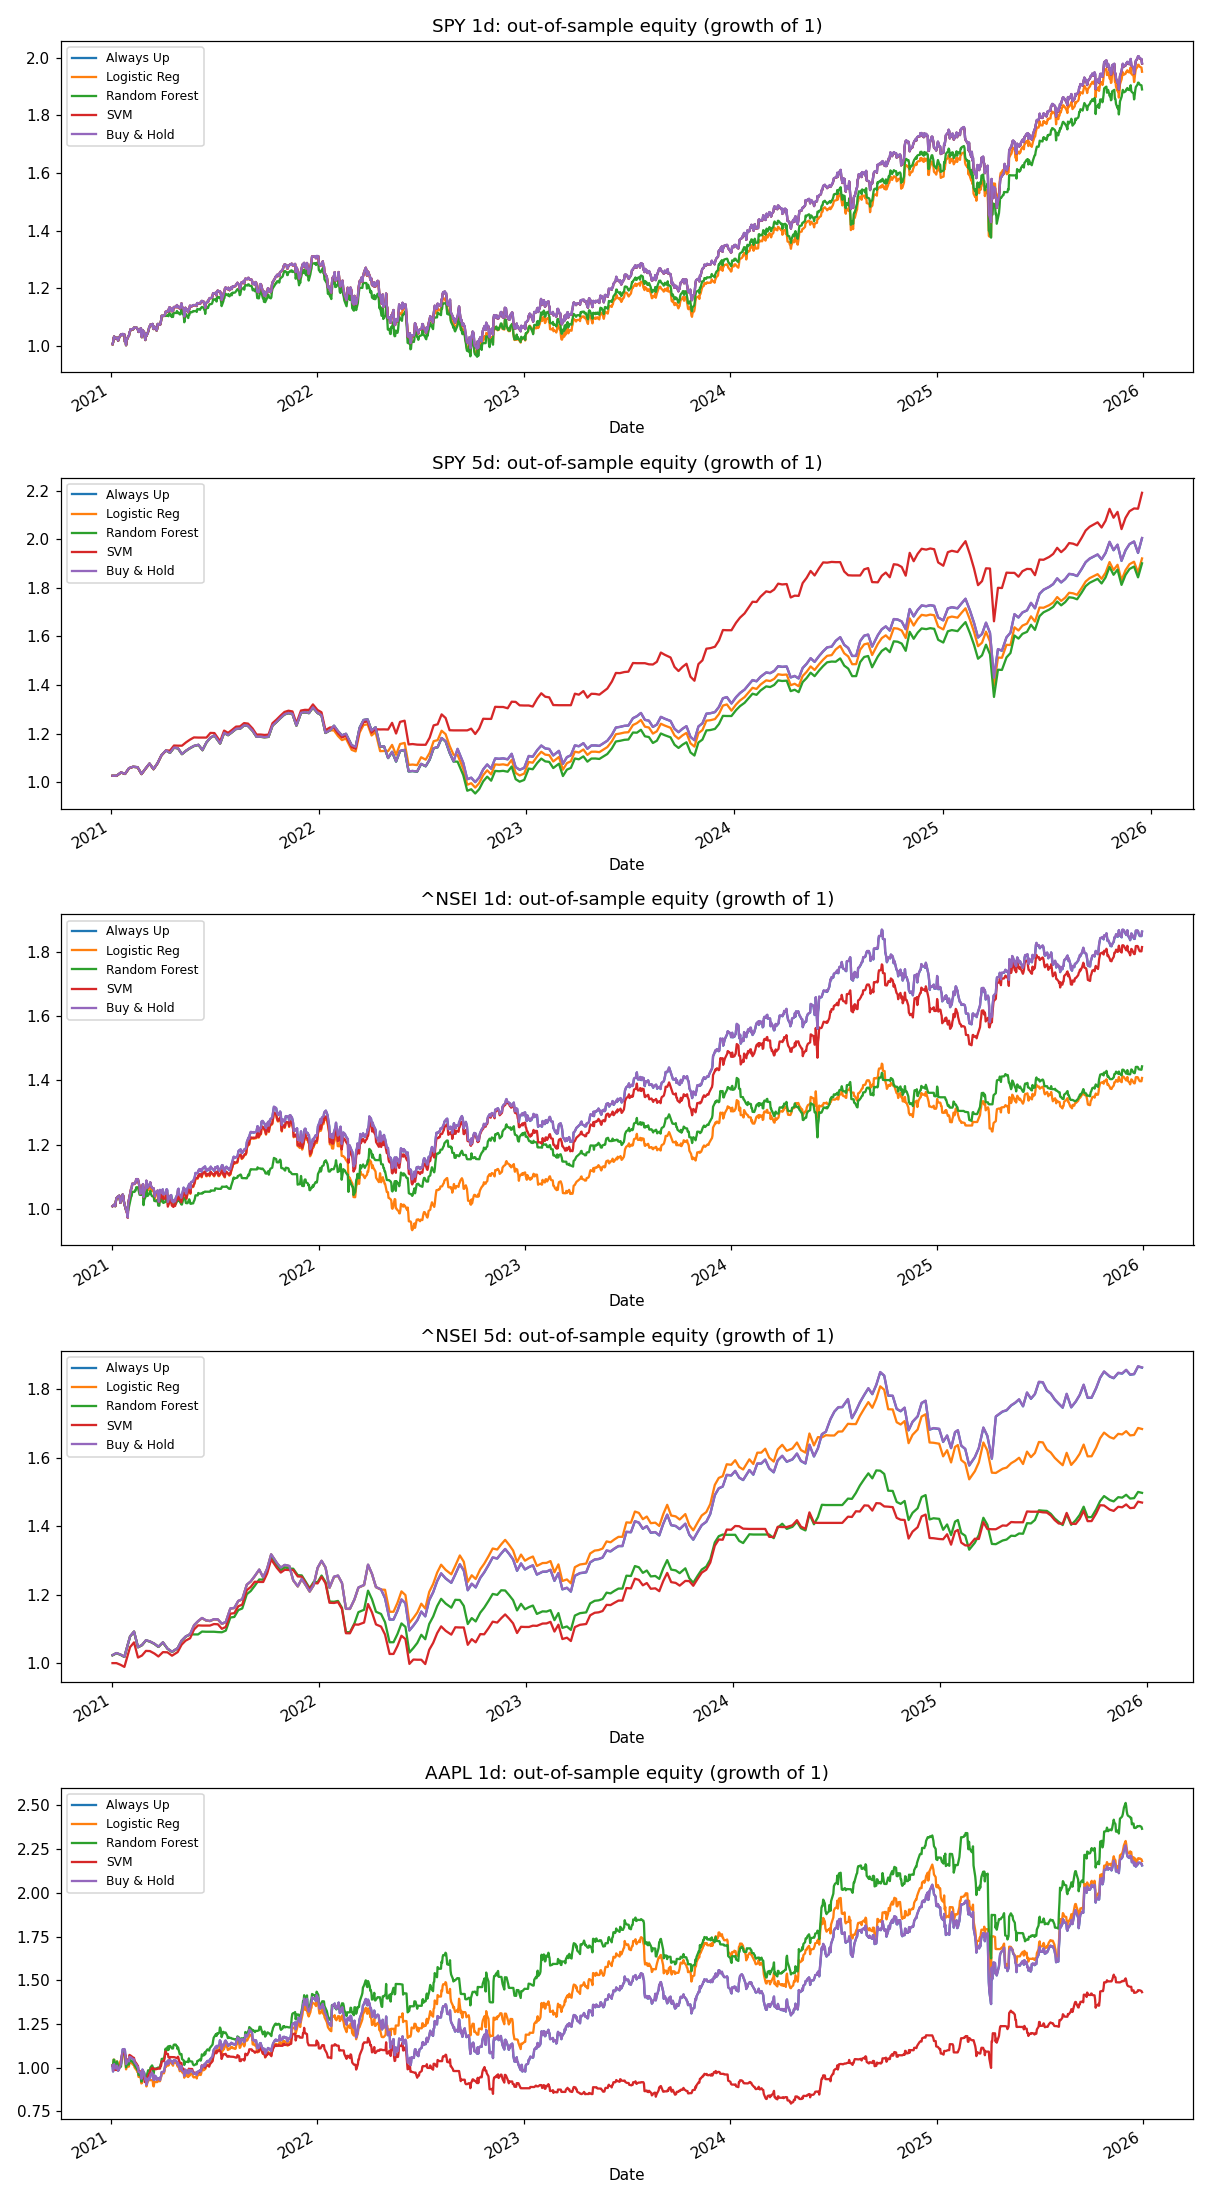

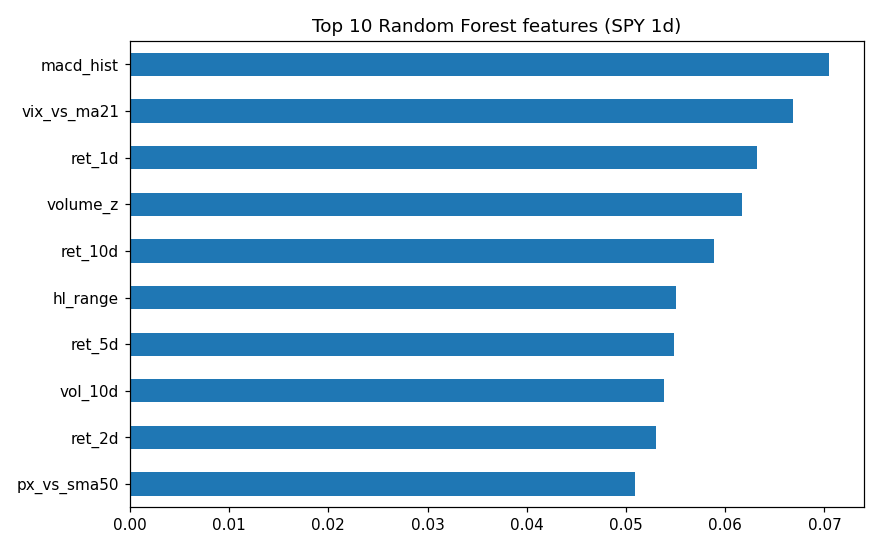

In [ ]:
!pip install -q yfinance
!python experiments.py
import os
from IPython.display import Image, display
for f in ["equity_curves_all.png", "feature_importance.png"]:
    if os.path.exists(f):
        display(Image(f))

In [3]:
import os, numpy as np, pandas as pd
if not os.path.exists("experiments.py"):
    raise SystemExit("experiments.py is missing (Colab restarted). Run Cell 1 again, then this cell.")
import experiments as E
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import ParameterGrid
pd.set_option("display.width", 250); pd.set_option("display.max_columns", None)
rng = np.random.default_rng(0)
print("Downloading VIX...")
VIX = E.load("^VIX")["Close"]

def prep(ticker, h):
    df = E.load(ticker)
    lag = 1 if ticker.startswith("^NSE") else 0
    vix = VIX.reindex(df.index.union(VIX.index)).ffill().shift(lag).reindex(df.index)
    v = df["Volume"]
    return E.make_dataset(df, vix, h, (v.isna() | (v <= 0)).mean() < 0.05)

def block_p(y, s, auc, n=1000, gap=63):
    yv, sv, N = y.values, s.values, len(y)
    hits = sum(roc_auc_score(np.roll(yv, rng.integers(gap, N - gap)), sv) >= auc for _ in range(n))
    return (hits + 1) / (n + 1)

def bt(preds, fwd, h, k=0):
    sig, ret = preds.iloc[k::h], fwd.iloc[k::h]
    strat = sig * ret - sig.diff().abs().fillna(sig.iloc[0]) * E.COST_BPS / 1e4
    return strat, ret

def sharpe(r, h):
    return E.perf(r, h)[0]["Sharpe"]

def evaluate(X, y, fwd, h, model, start, end=None):
    E.TEST_START = pd.Timestamp(start)
    preds, scores = E.walk_forward(model, X, y, h)
    if end:
        keep = preds.index < pd.Timestamp(end)
        preds, scores = preds[keep], scores[keep]
    yt, ft = y.loc[preds.index], fwd.loc[preds.index]
    return preds, scores, yt, ft, roc_auc_score(yt, scores)

CANDIDATES = [("SPY", 5, "SVM"), ("^NSEI", 1, "Random Forest")]
verdicts = []

for ticker, h, mname in CANDIDATES:
    title = f"{ticker} {h}d / {mname}"
    print("\n" + "=" * 90 + f"\nROBUSTNESS CHECK: {title}\n" + "=" * 90)
    X, y, fwd = prep(ticker, h)
    base, grid = E.model_specs()[mname]
    passed = 0

    tr = X.index < pd.Timestamp("2021-01-01")
    model, params, _ = E.tune(base, grid, X[tr], y[tr], h)
    preds, scores, yt, ft, auc = evaluate(X, y, fwd, h, model, "2021-01-01")
    p = block_p(yt, scores, auc)
    ok1 = p < 0.05; passed += ok1
    print(f"\n[1] Stricter significance test (2021 onward, params {params})")
    print(f"    AUC {auc:.3f}   block-permutation p-value {p:.3f}   -> {'PASS' if ok1 else 'FAIL'}")

    rows = []
    for k in range(h):
        s, r = bt(preds, ft, h, k)
        rows.append({"start_offset": k, "Sharpe": sharpe(s, h), "BH_Sharpe": sharpe(r, h)})
    t2 = pd.DataFrame(rows)
    wins = (t2["Sharpe"] > t2["BH_Sharpe"]).mean()
    ok2 = wins >= 0.8; passed += ok2
    print(f"\n[2] Beats Buy & Hold across rebalancing start days ({wins:.0%} of them) -> {'PASS' if ok2 else 'FAIL'}")
    print(t2.round(3).to_string(index=False))

    s, r = bt(preds, ft, h, 0)
    yrs = []
    for yr in sorted(set(preds.index.year)):
        m = preds.index.year == yr
        ms, mr = s.index.year == yr, r.index.year == yr
        a = roc_auc_score(yt[m], scores[m]) if yt[m].nunique() > 1 else np.nan
        yrs.append({"Year": yr, "AUC": a, "Strategy_ret": (1 + s[ms]).prod() - 1, "BH_ret": (1 + r[mr]).prod() - 1})
    t3 = pd.DataFrame(yrs)
    good_years = (t3["AUC"] > 0.5).sum()
    ok3 = good_years >= len(t3) - 1; passed += ok3
    print(f"\n[3] Year by year (AUC above 0.5 in {good_years} of {len(t3)} years) -> {'PASS' if ok3 else 'FAIL'}")
    print(t3.round(3).to_string(index=False))

    tr16 = X.index < pd.Timestamp("2016-01-01")
    model16, params16, _ = E.tune(base, grid, X[tr16], y[tr16], h)
    p16, s16, yt16, ft16, auc16 = evaluate(X, y, fwd, h, model16, "2016-01-01", "2021-01-01")
    pv16 = block_p(yt16, s16, auc16)
    st16, r16 = bt(p16, ft16, h, 0)
    ok4 = pv16 < 0.05; passed += ok4
    print(f"\n[4] Fresh period 2016-2020 (params {params16})")
    print(f"    AUC {auc16:.3f}   p-value {pv16:.3f}   Sharpe {sharpe(st16, h):.3f} vs Buy & Hold {sharpe(r16, h):.3f}"
          f"   -> {'PASS' if ok4 else 'FAIL'}")

    rows = []
    for gp in ParameterGrid(grid):
        m = clone(base).set_params(**gp)
        _, sc, ytt, _, a = evaluate(X, y, fwd, h, m, "2021-01-01")
        rows.append({**gp, "AUC": a})
    t5 = pd.DataFrame(rows)
    share = (t5["AUC"] > 0.52).mean()
    ok5 = share >= 0.5; passed += ok5
    print(f"\n[5] All settings tried (AUC above 0.52 for {share:.0%} of them) -> {'PASS' if ok5 else 'FAIL'}")
    print(t5.round(3).to_string(index=False))

    verdicts.append((title, passed))
    E.TEST_START = pd.Timestamp("2021-01-01")

print("\n" + "=" * 90 + "\nFINAL ROBUSTNESS VERDICT\n" + "=" * 90)
for title, passed in verdicts:
    label = "LIKELY REAL" if passed >= 4 else ("MIXED" if passed >= 2 else "LIKELY LUCK")
    print(f"{title:<28} passed {passed}/5 tests  ->  {label}")
print("\nDONE")


ROBUSTNESS CHECK: SPY 5d / SVM

[1] Stricter significance test (2021 onward, params {'svc__C': 10.0, 'svc__gamma': 'scale'})
    AUC 0.557   block-permutation p-value 0.003   -> PASS

[2] Beats Buy & Hold across rebalancing start days (100% of them) -> PASS
 start_offset  Sharpe  BH_Sharpe
            0   1.177      0.924
            1   1.026      0.943
            2   1.346      0.978
            3   1.064      0.929
            4   1.096      0.888

[3] Year by year (AUC above 0.5 in 5 of 5 years) -> PASS
 Year   AUC  Strategy_ret  BH_ret
 2021 0.574         0.297   0.286
 2022 0.590         0.014  -0.176
 2023 0.507         0.235   0.250
 2024 0.537         0.172   0.267
 2025 0.530         0.150   0.195

[4] Fresh period 2016-2020 (params {'svc__C': 10.0, 'svc__gamma': 'scale'})
    AUC 0.554   p-value 0.010   Sharpe 1.046 vs Buy & Hold 0.920   -> PASS

[5] All settings tried (AUC above 0.52 for 100% of them) -> PASS
 svc__C svc__gamma   AUC
    0.1      scale 0.560
    0.1      